In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Crop_recommendation.csv")
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


<Axes: xlabel='temperature', ylabel='Count'>

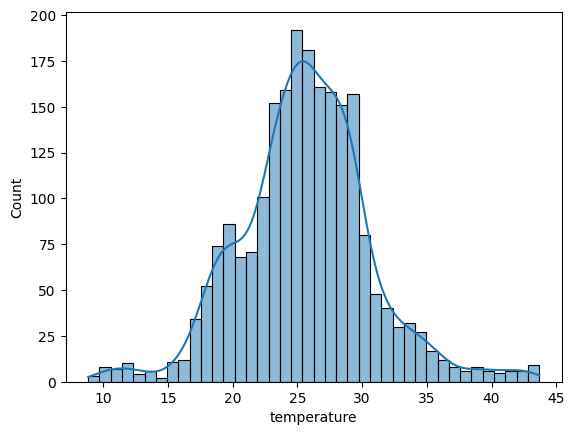

In [3]:
sns.histplot(data=df,x="temperature",kde=True)
# plt.show()
# temperature values range from approximately 10degree celcius to 43degree celcius
# most values are concentrated between 20 degree celcius and 30 degree celcius with a peak around 25 degree celcius
# a few extreme balues are observed near both endsof the range

<Axes: xlabel='N', ylabel='Count'>

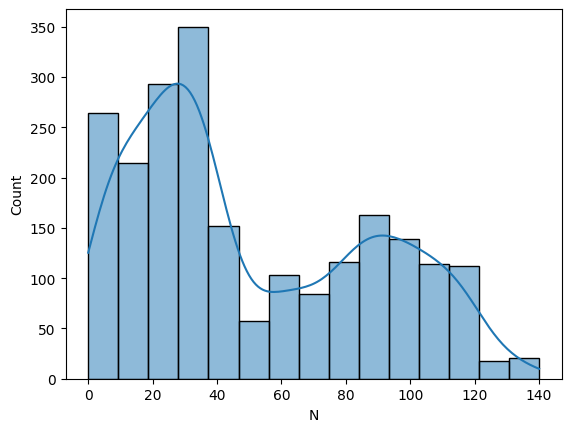

In [4]:
sns.histplot(data=df,x="N",kde=True)
# nitrogen values range from approximately 0 to 140 
# most values are concentrated around 0 to 40 with a peak around 30 to 40
#  the distributions are right skewed indicating some high nitogen values  

<Axes: xlabel='P', ylabel='Count'>

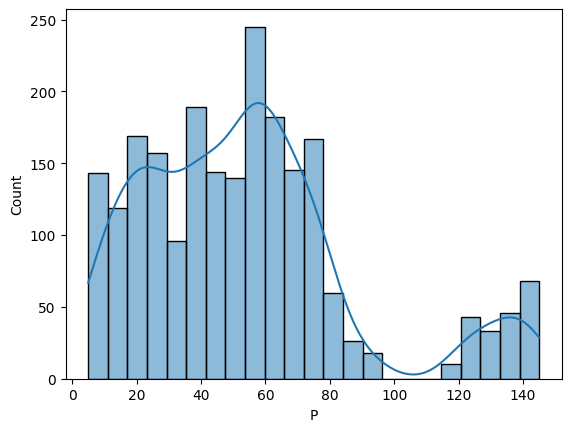

In [5]:
sns.histplot(data=df,x="P",kde=True)
# phospheres values range from  5 to 140
# most values are concetrated around  40 to 80 with a peak around 50 to 60
# the distributions are right skewed indicating some high phospheres values
# no values is present between values 100 and 110

<Axes: xlabel='K', ylabel='Count'>

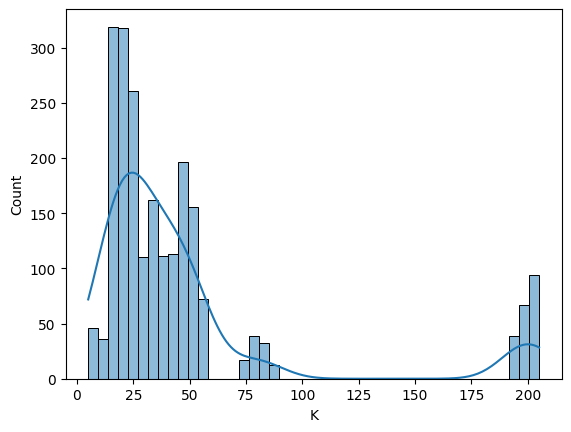

In [6]:
sns.histplot(data=df,x="K",kde=True)
# potassium values range from approximately 10 to 200
# most values are concenterated around 20 and 25 with a peak around 20
# the distributions are extremelu right skewed with a lot of outliers
# now values is present b/w 100 and 190 also around 50 to 75


<Axes: xlabel='humidity', ylabel='Count'>

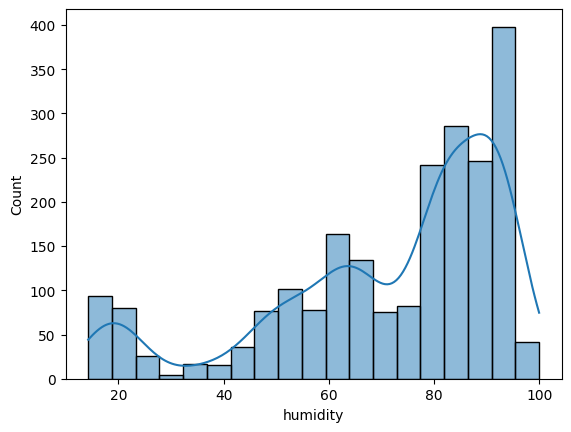

In [7]:
sns.histplot(data=df,x="humidity",kde=True)
# humidity values range from approximately 10 to 100
# most values are concentrated around 80 and 100 with a peak around 95
# the distributions are left skewed indicating some low humidity

<Axes: xlabel='ph', ylabel='Count'>

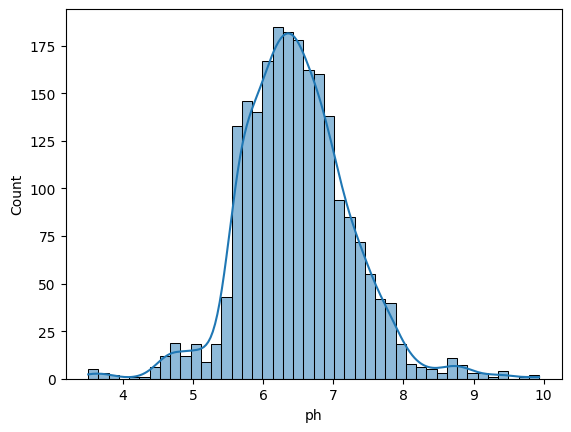

In [8]:
sns.histplot(data=df,x="ph",kde=True)
# ph ranges from approximately 4 to10
# most values are concenterated around 6 and 7

<Axes: xlabel='rainfall', ylabel='Count'>

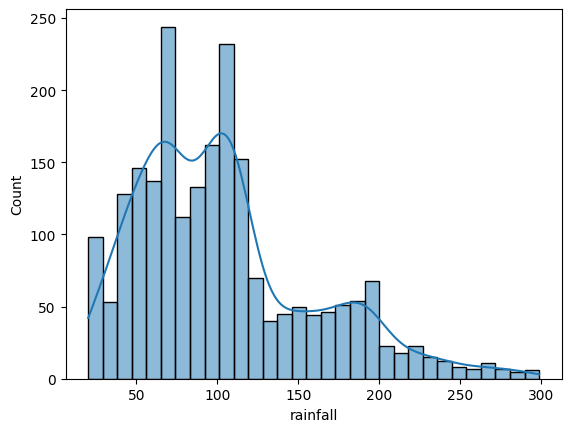

In [9]:
sns.histplot(data=df,x="rainfall",kde=True)
# rainfall values ranges from 20 to 300
# most values are concentrated around 50 to 110 with a peak around 60
# the distribution are right skewed with lot of high valued outliers

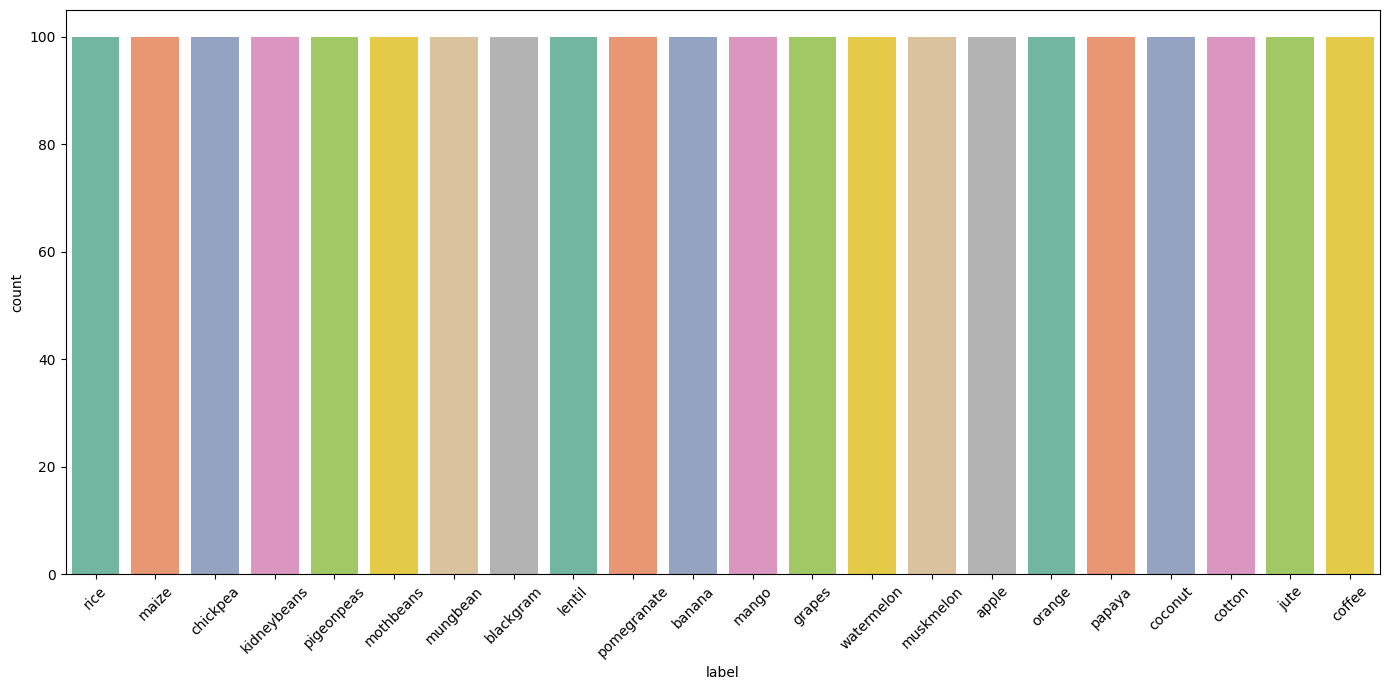

In [10]:
plt.figure(figsize=(14,7))
sns.countplot(data=df,x="label",hue="label",palette="Set2")
plt.xticks(rotation=45)
plt.tight_layout()
# There are 22 unique crop classes (target labels), each having approximately 100 samples.
# all the crops are equally represented 
#  i assume that the dataset is balanced .
# This is beneficial for machine learning models, as it prevents bias toward any particular crop and ensures fair learning across all classes.
# Since the dataset is balanced, evaluation metrics such as accuracy will be reliable, and the model will not favor any specific crop during prediction.

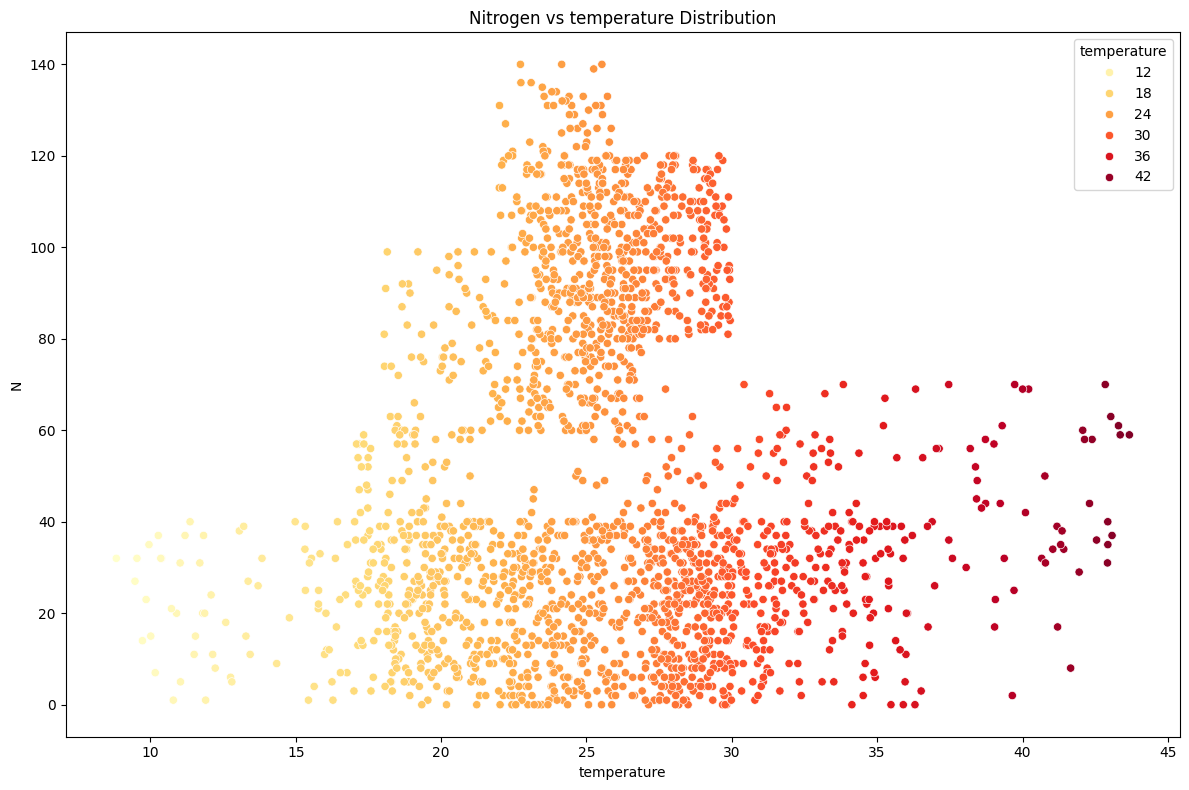

In [11]:
plt.figure(figsize=(12,8))
# crop=df.pivot_table(index="N",columns="temperature",aggfunc='size',fill_value=0)
# sns.heatmap(crop,annot=True,cmap="YlOrRd",fmt='d')
sns.scatterplot(data=df,x="temperature",y="N",hue="temperature",palette="YlOrRd")
plt.title("Nitrogen vs temperature Distribution")
plt.tight_layout()
# Nitrogen values vary widely across all temperature ranges. 
# There is no strong clear pattern, suggesting nitrogen requirement is not strictly dependent on temperature.

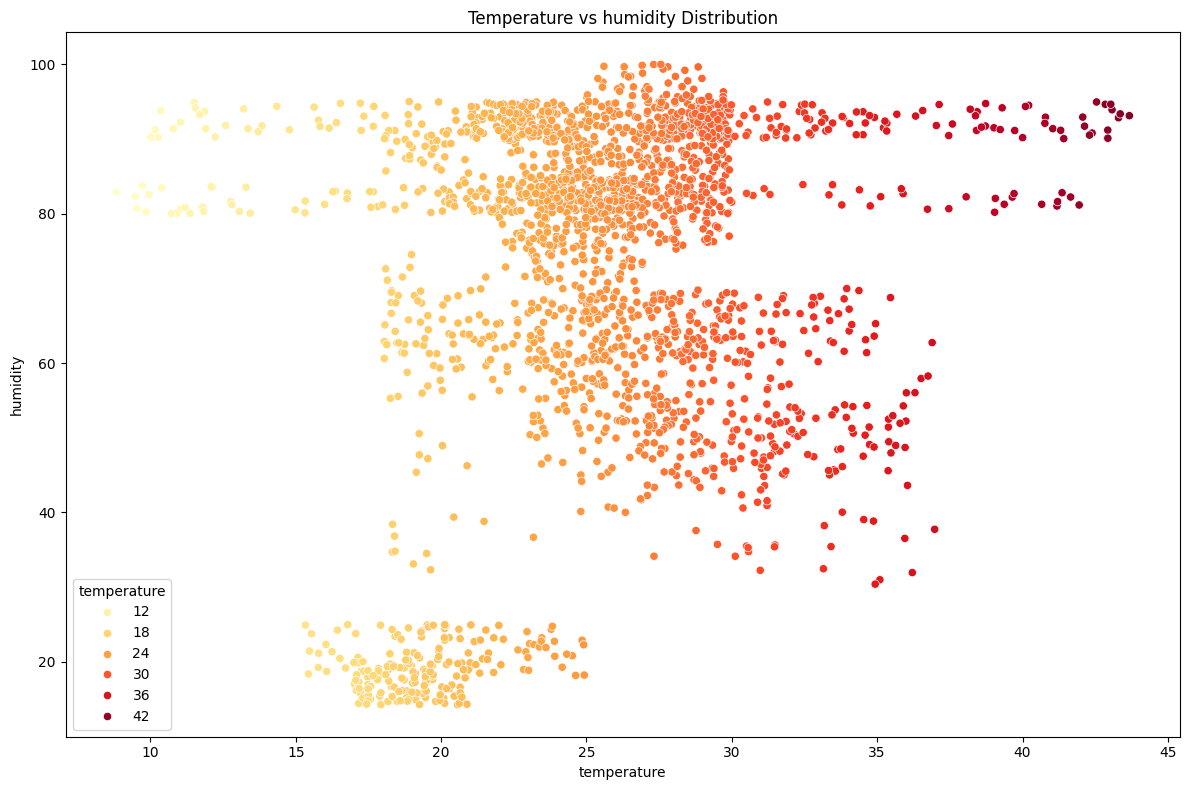

In [12]:
plt.figure(figsize=(12,8))
# crop=df.pivot_table(index="temperature",columns="humidity",aggfunc='size',fill_value=0)
# sns.heatmap(crop,annot=True,cmap="YlOrRd",fmt='d')
sns.scatterplot(data=df,x="temperature",y="humidity",hue="temperature",palette="YlOrRd")
plt.title("Temperature vs humidity Distribution")
plt.tight_layout()
# Most data points are concentrated in high humidity (70–100) and moderate temperature (20–30°C). 
# Some crops exist in low temperature and low humidity regions, indicating variation in growing conditions.

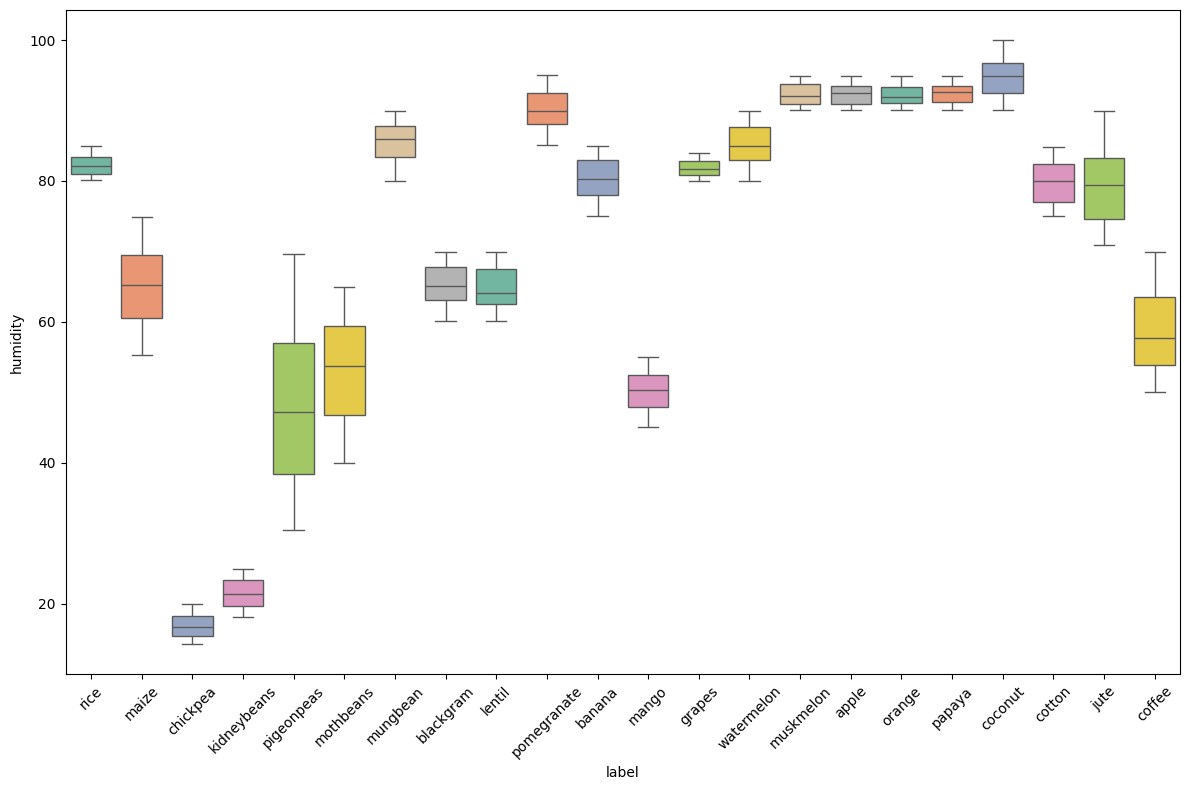

In [13]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x="label",y="humidity",hue="label",palette="Set2")
plt.xticks(rotation=45)
# plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
# Crops like pomegranate, muskmelon,orange,pappaya,coconut and apple shows that they need high humidity to grow between 90 to 100.
# Crops like chickpea, kidneybeans tend to grow in lower humidity  ranges, indicating preference for cold climates.
# Crops like rice, maize, banana,mungmean,etc grow in moderate humidity ranges (around 60–90), suggesting adaptability to typical tropical conditions.
# pigeonpeas and mothbeans,coffee show high variability in humidity, suggesting these crops can tolerate a wider range of environmental conditions.
# Most crops have median humidity around 60–90, indicating that this temperature range is optimal for the majority of crops in the dataset.
# Some crops show extreme humidity values (both low and high), indicating occasional growth under unusual environmental conditions.

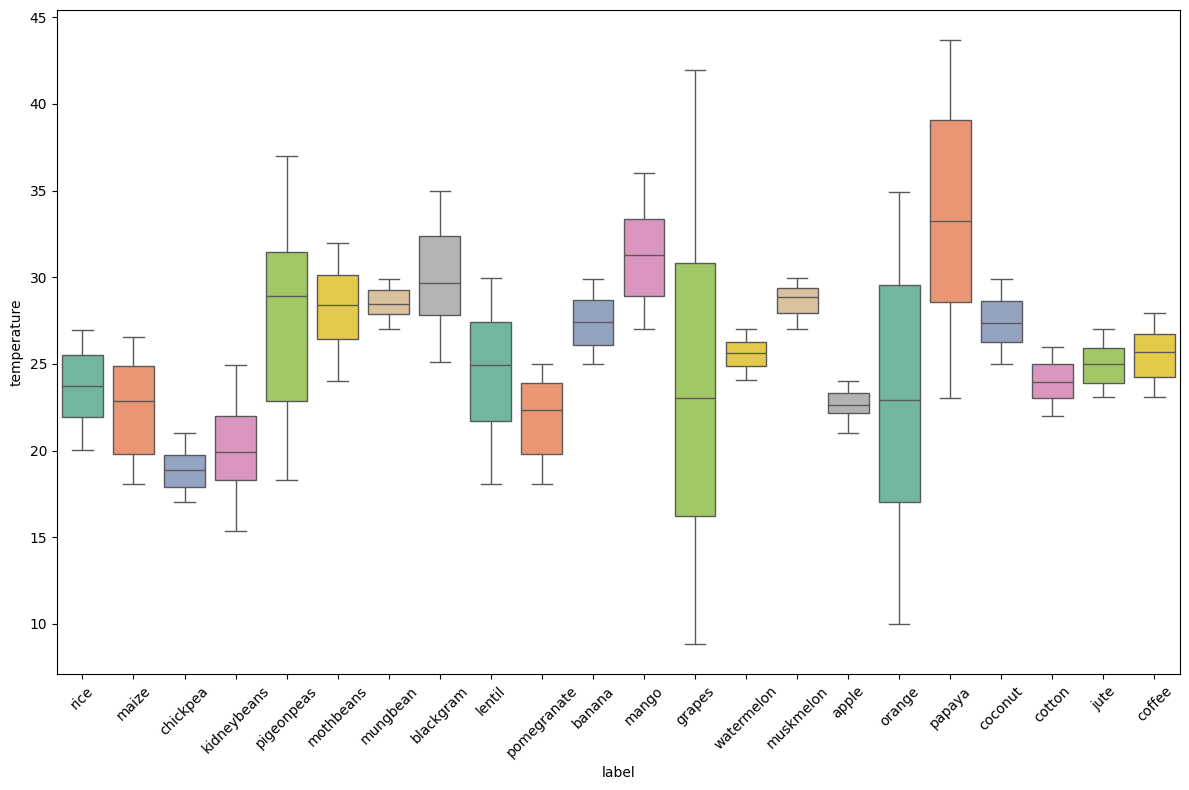

In [14]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x="label",y="temperature",hue="label",palette="Set2")
plt.xticks(rotation=45)
plt.tight_layout()
# Grapes can grow across a wide range of temperatures, indicating high adaptability to different climatic conditions.
# Chickpea grows in relatively lower temperature ranges compared to most crops, indicating suitability for cooler climates.
# Papaya grows in higher temperature ranges, reaching up to around 40°C, indicating preference for warmer climates.
# Crops like muskmelon, watermelon, and apple show a narrow temperature range, indicating they require more stable and specific temperature conditions.
# Grapes and orange show high variability in temperature, suggesting these crops can tolerate a wider range of environmental conditions.
# Most crops have median temperatures around 25–30°C, indicating that this temperature range is optimal for the majority of crops in the dataset.
# Some crops show extreme temperature values (both low and high), indicating occasional growth under unusual environmental conditions.

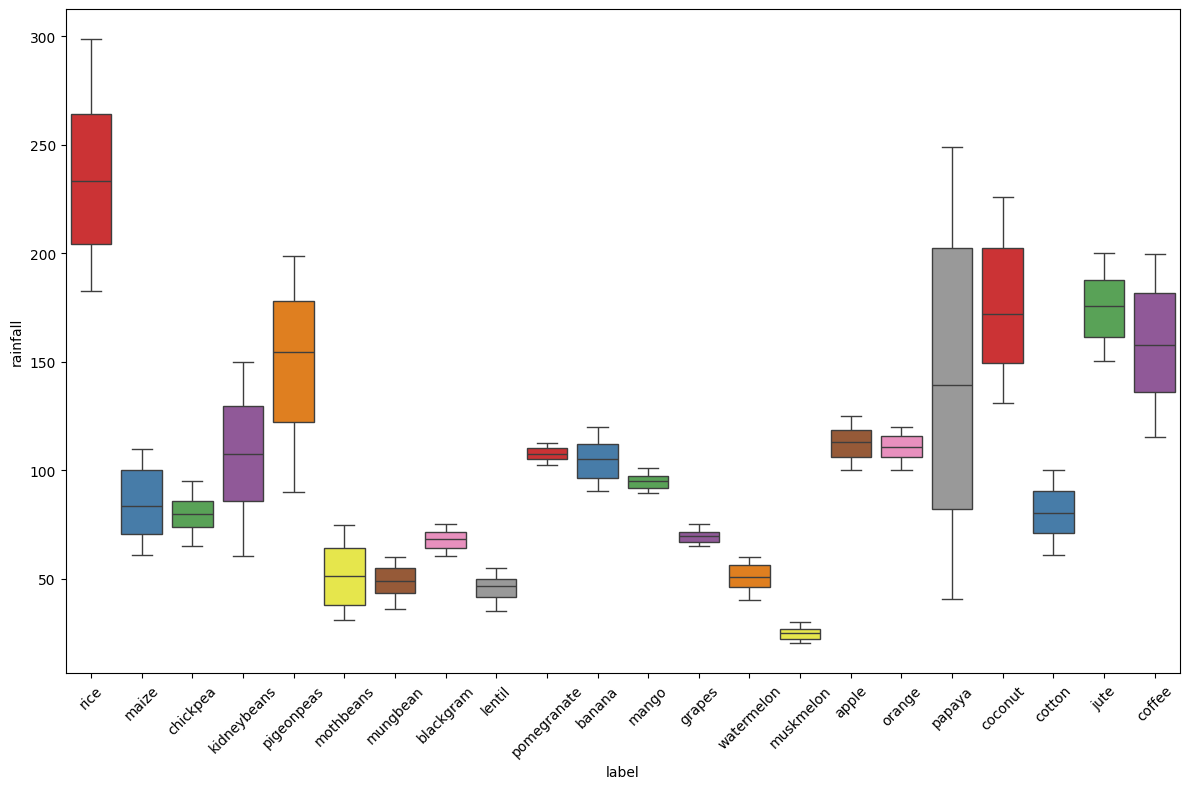

In [15]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x="label",y="rainfall",hue="label",palette="Set1")
plt.xticks(rotation=45)
plt.tight_layout()
# rice is the crop which needs the most rainfall . it needs atleast from 200cm to 300cm of rainfall accordign to this dataset.indicating it is highly dependent on water-rich environments.
# papaya is the only crop which can survive on a large varity of rainfalls from 50cm to 250cm .it can survive on droughts and high rainy areas.indicating high adaptability to both low and high rainfall conditions
# muskmelon,watermelon,lentil,and mungbean can survive on low rainfall regions indicating drought tolerance .
# other crops can grow on areas that get moderate rainfall from 50cm to 200cm.
# Crops like muskmelon and watermelon have a very narrow rainfall range, indicating they require specific and controlled water conditions.
# Coconut prefers relatively high rainfall (around 150–220 mm), indicating suitability for humid and coastal regions.
# Most crops have median rainfall values between 80–150 mm, indicating this is an optimal rainfall range for crop growth in the dataset.  

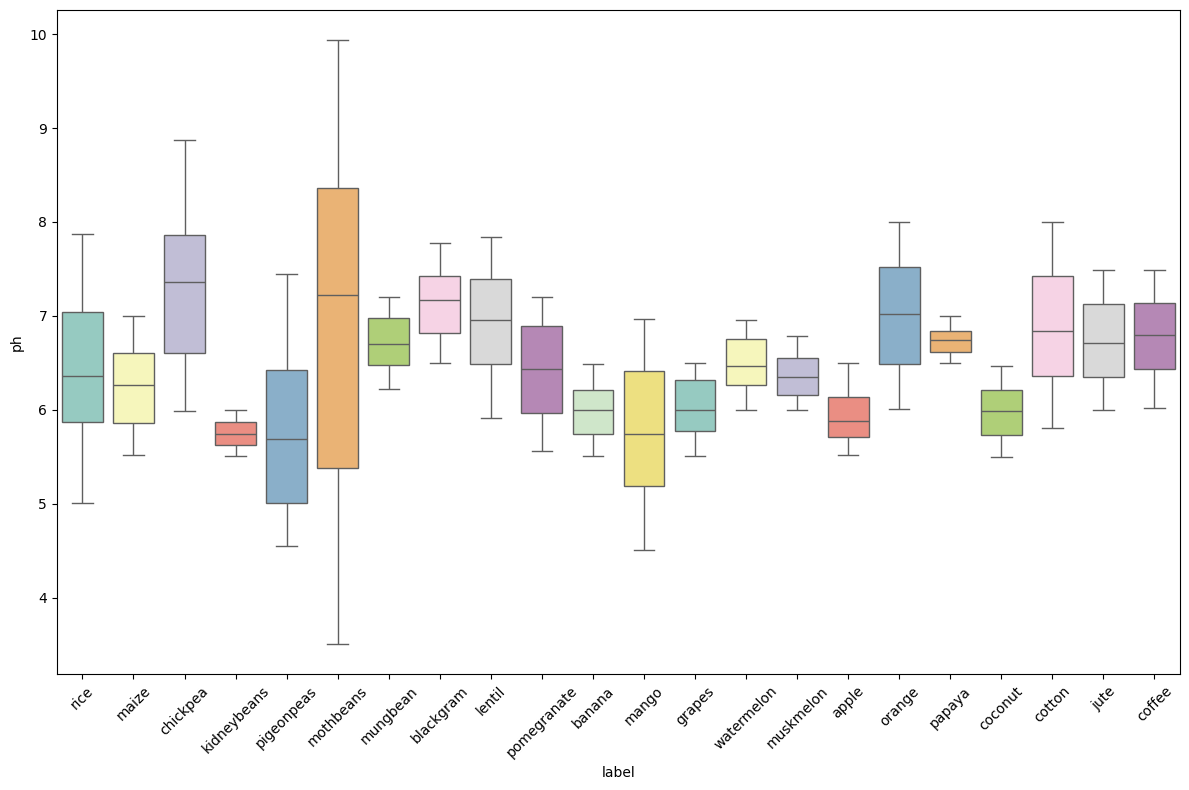

In [16]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x="label",y="ph",hue="label",palette="Set3")
plt.xticks(rotation=45)
plt.tight_layout()
# mothbeans can grow on soils which have a varity of ph level ranging from 3 to 9 .making it the crop which can grow on any soil and has the chance of surviving longer
# all the other crops can only grow on a ph level ranging from 5 to 8 .indicating that slightly acidic to neutral soils are optimal for agriculture.
# pappaya and kidney beans have the lowest range of ph making these crops less choosable for soils with high or low ph.indicating they require more specific soil conditions.
# Most crops have median pH values around 6–7, suggesting neutral soil is ideal for the majority of crops.
# Crops with narrow pH ranges (e.g., kidneybeans, chickpea) are more sensitive to soil conditions.
# Some crops prefer slightly acidic soil (pH < 6), indicating variation in soil preference across crops.

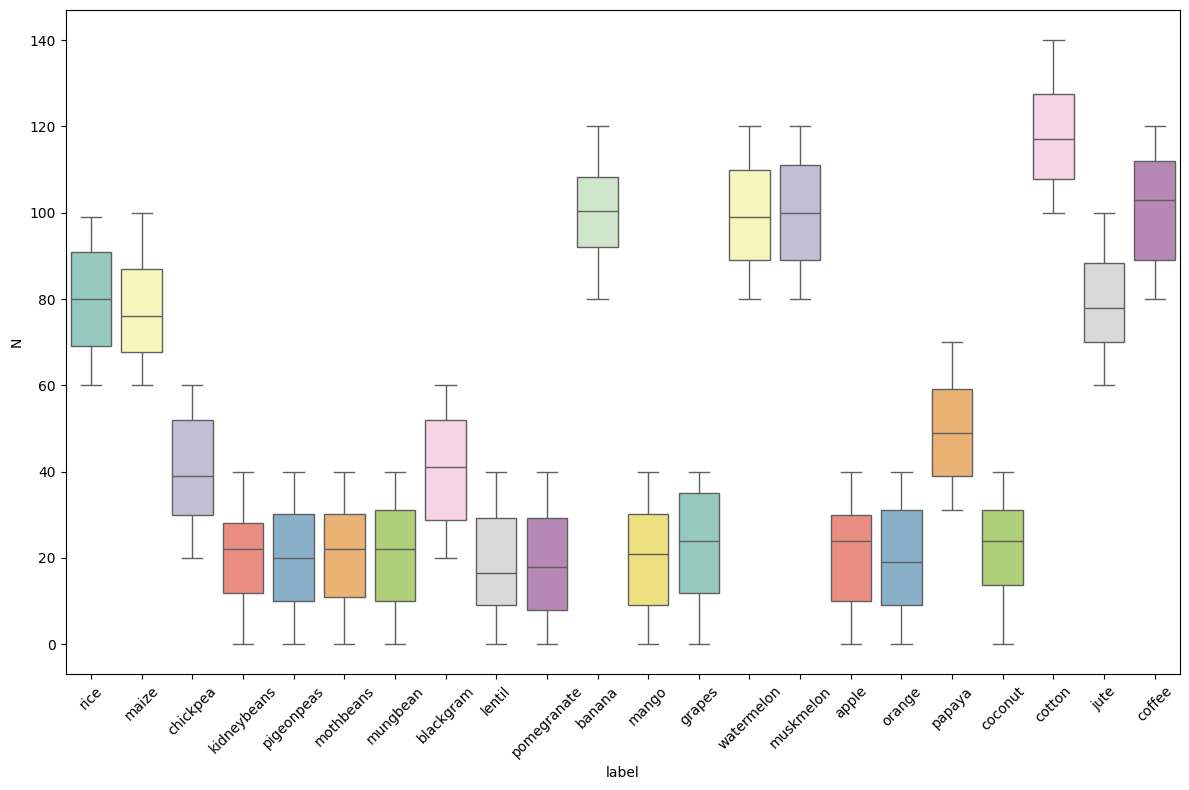

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x="label",y="N",hue="label",palette="Set3")
plt.xticks(rotation=45)
plt.tight_layout()
# Cotton stands out significantly as the crop requiring the highest amount of Nitrogen, with its median sitting around 120 and a range spanning approximately from 100 to 140. Other high-nitrogen crops include Banana, Coffee, Muskmelon, and Watermelon, which all consistently require Nitrogen levels above 80.
# There is a large cluster of crops that require very low Nitrogen (medians below 40). Crucially, this group contains all the leguminous crops (chickpea, kidneybeans, lentil, mothbeans, mungbean, pigeonpeas). This makes biological sense, as legumes fix their own nitrogen from the atmosphere. Several fruits, like apples, grapes, and pomegranates, also share this low-nitrogen profile.
# The Nitrogen requirements are highly polarized. Crops generally fall into one of two distinct categories: a "High Nitrogen" group (requiring >60) or a "Low Nitrogen" group (requiring <40). There is a stark gap in the middle; almost no crop in this dataset has a median Nitrogen requirement in the 40–60 range.
# Crops such as Cotton, Banana, Jute, Maize, and Rice feature very tall boxes (large interquartile ranges) and long whiskers. This high variance indicates that these crops can tolerate—or are grown in—a much wider variety of Nitrogen levels.
# Conversely, many of the low-nitrogen crops (like Apple, Grapes, Kidneybeans, and Lentil) have highly compressed, "squished" boxes. This low variance implies they have very strict, narrow Nitrogen requirements and might be sensitive to over-fertilization if Nitrogen levels fluctuate even slightly beyond their specific range.

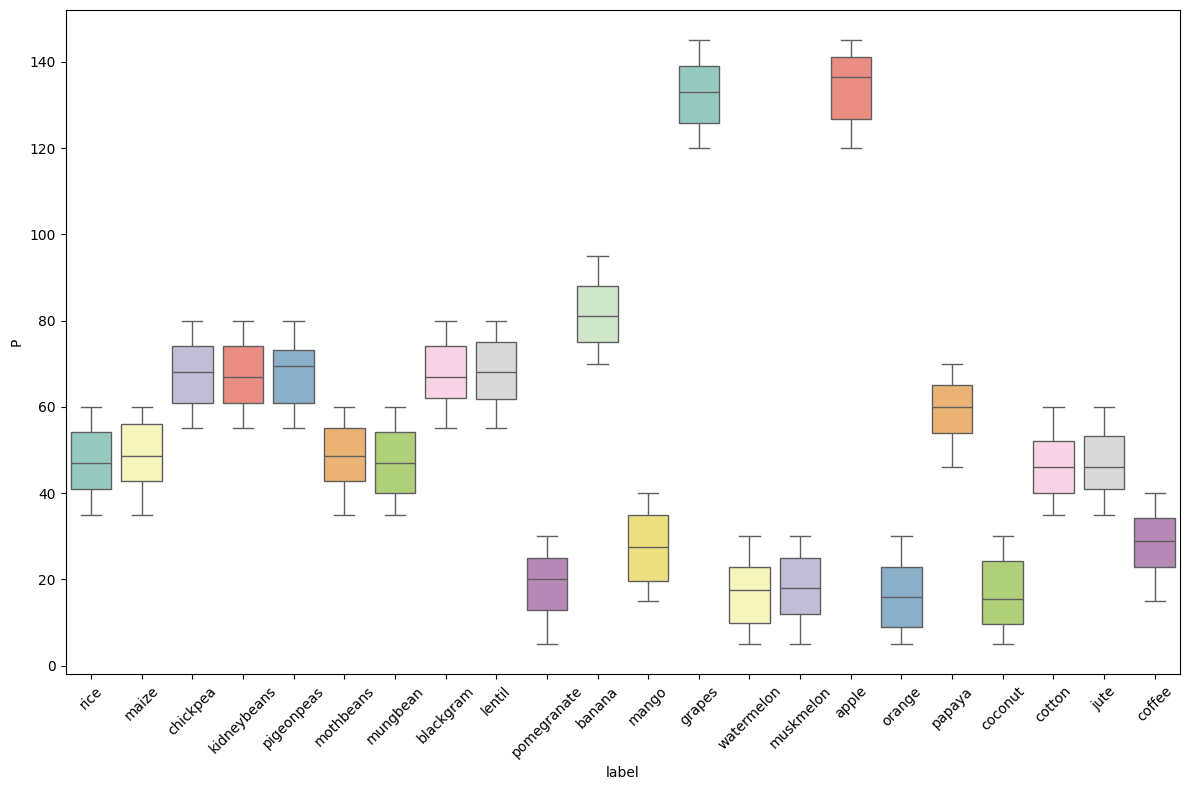

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x="label",y="P",hue="label",palette="Set3")
plt.xticks(rotation=45)
plt.tight_layout()
# There is a massive gap between the top two crops and everything else. Grapes and Apples are extreme outliers in the dataset, requiring drastically higher Phosphorus levels (with medians well above 120) compared to all other crops.
# All the pulse and legume crops (pigeonpeas, mothbeans, mungbean, blackgram, lentil, chickpea, and kidneybeans) form a very clear mid-range cluster. Their Phosphorus requirements consistently sit between roughly 55 and 90, making them distinct from both the high-consuming fruits and the low-consuming general crops.
# A massive cluster of crops—including most other fruits (banana, mango, orange, papaya, watermelon) and cash crops (cotton, coffee, coconut, jute)—have very low Phosphorus needs. Their median values are all tightly packed below the 40 mark, mostly hovering in the 10–30 range.
# Notice how "squished" and short almost all of the boxes are. Unlike Nitrogen, which showed long boxes (high variance) for several crops, this plot shows that almost every crop has a very narrow and specific Phosphorus requirement. This indicates that farmers have very little room for error when applying Phosphorus fertilizers for these specific crops.

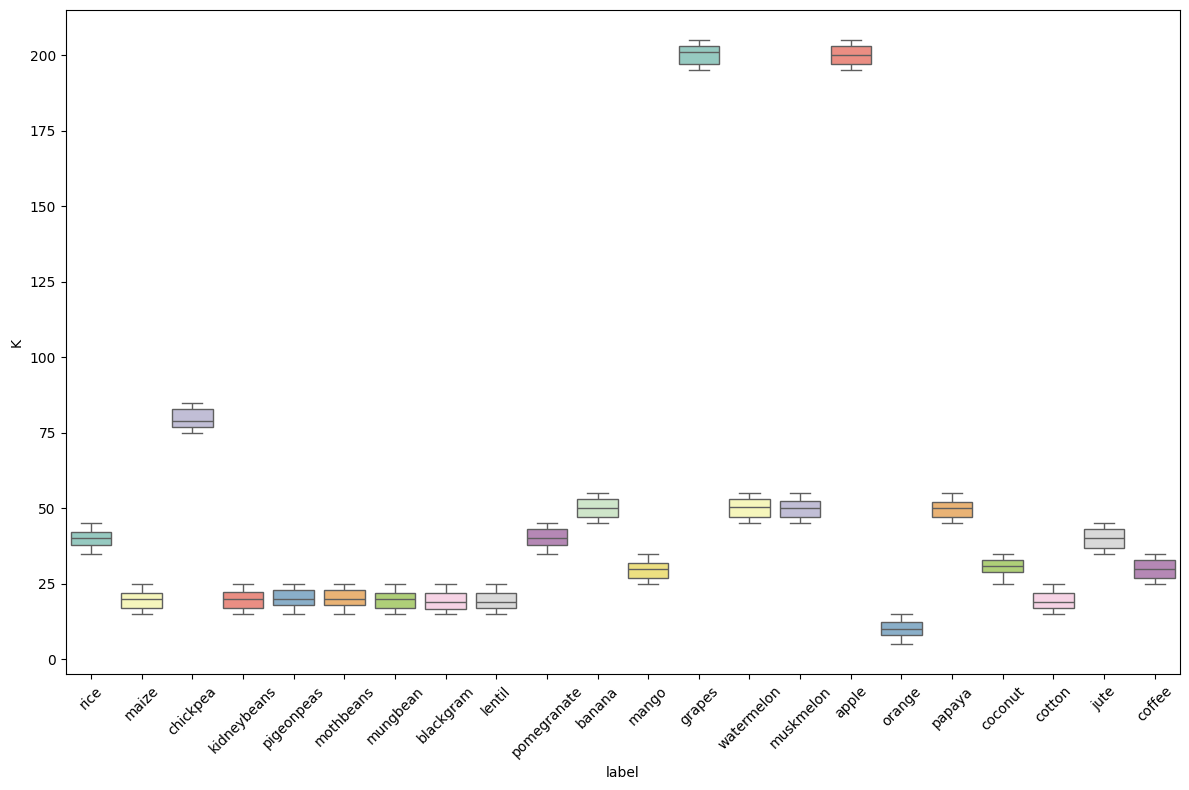

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x="label",y="K",hue="label",palette="Set3")
plt.xticks(rotation=45)
plt.tight_layout()
# Just like with Phosphorus, Apples and Grapes stand entirely apart from the rest of the dataset. They require massively higher Potassium levels (with medians near 200), creating a massive visual gap between them and every other crop on the chart
# Aside from those two extreme fruits, almost every other crop—whether it is a grain, a legume, or another fruit—clusters tightly at the bottom of the chart. Their Potassium requirements are very low, with almost all of their medians falling below the 60 mark.
# Similar to what we saw in the Phosphorus plot, the boxes for almost all crops are highly compressed ("squished"). This low variance indicates that Potassium requirements are very specific for each crop. Farmers must be precise with Potassium fertilizers, as these crops do not tolerate wide fluctuations in this nutrient.